# GA1-240201064-04-AA1-EV08
## Generacion de visualizaciones: estructura y tipos de graficas en Matplotlib

Notebook organizado para replicar ejercicios obligatorios del material:

- A. Estructura de una grafica
- B. Interfaz Pyplot vs OO
- C. Graficas univariantes (10)
- D. Graficas bivariantes (10)
- E. Graficas categoricas (4)

> Todas las figuras se guardan en `artifacts/ev08` usando `savefig()`.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

# Semilla para reproducibilidad
rng = np.random.default_rng(seed=42)

# Rutas de trabajo
NOTEBOOK_DIR = Path.cwd()
ARTIFACTS_DIR = (NOTEBOOK_DIR / '..' / 'artifacts' / 'ev08').resolve()
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

# Resolver ruta del dataset principal (soporta data/raw o data/Raw)
candidate_paths = [
    NOTEBOOK_DIR / '..' / 'data' / 'raw' / 'dataset.csv',
    NOTEBOOK_DIR / '..' / 'data' / 'Raw' / 'dataset.csv',
    NOTEBOOK_DIR / 'data' / 'raw' / 'dataset.csv',
    NOTEBOOK_DIR / 'data' / 'Raw' / 'dataset.csv',
]

DATASET_PATH = None
for p in candidate_paths:
    if p.exists():
        DATASET_PATH = p.resolve()
        break

if DATASET_PATH is None:
    raise FileNotFoundError('No se encontro dataset.csv en data/raw o data/Raw')

print('Notebook dir:', NOTEBOOK_DIR)
print('Dataset:', DATASET_PATH)
print('Artifacts:', ARTIFACTS_DIR)


Notebook dir: C:\Users\WILLY-A\Desktop\Ciencia de datos\proyecto_ds\notebooks
Dataset: C:\Users\WILLY-A\Desktop\Ciencia de datos\proyecto_ds\data\Raw\dataset.csv
Artifacts: C:\Users\WILLY-A\Desktop\Ciencia de datos\proyecto_ds\artifacts\ev08


In [2]:
# Carga del dataset principal para ejercicios reales

df = pd.read_csv(DATASET_PATH)
print('Shape:', df.shape)
print('Columnas:', list(df.columns))
df.head(3)


Shape: (16598, 11)
Columnas: ['Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82


## A) Estructura de una grafica

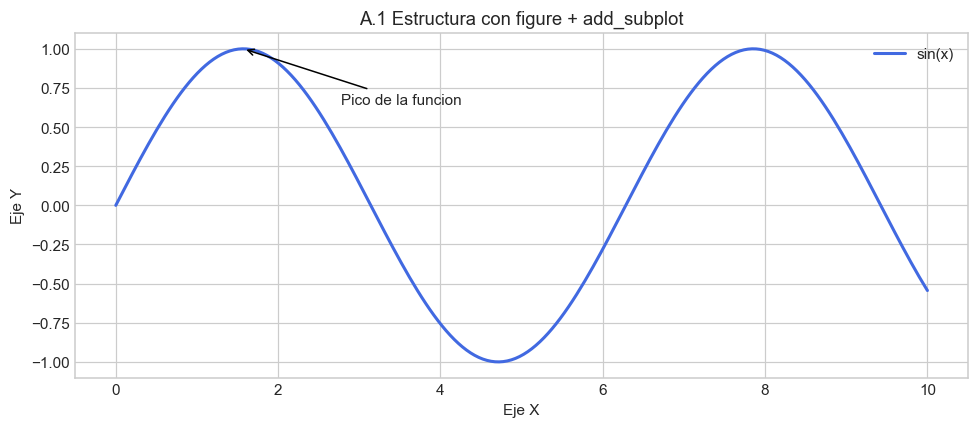

In [3]:
# A.1 Figura con plt.figure() + add_subplot()
# Incluye titulo, etiquetas, leyenda y anotaciones
x = np.linspace(0, 10, 200)
y = np.sin(x)

fig = plt.figure(figsize=(9, 4), dpi=110)
ax = fig.add_subplot(111)
ax.plot(x, y, color='royalblue', linewidth=2, label='sin(x)')
ax.set_title('A.1 Estructura con figure + add_subplot')
ax.set_xlabel('Eje X')
ax.set_ylabel('Eje Y')
ax.legend()

x_p = np.pi / 2
y_p = np.sin(x_p)
ax.annotate('Pico de la funcion', xy=(x_p, y_p), xytext=(x_p + 1.2, y_p - 0.35),
            arrowprops=dict(arrowstyle='->', color='black'))

fig.tight_layout()
fig.savefig(ARTIFACTS_DIR / 'A1_figure_add_subplot.png', dpi=300, bbox_inches='tight')
plt.show()


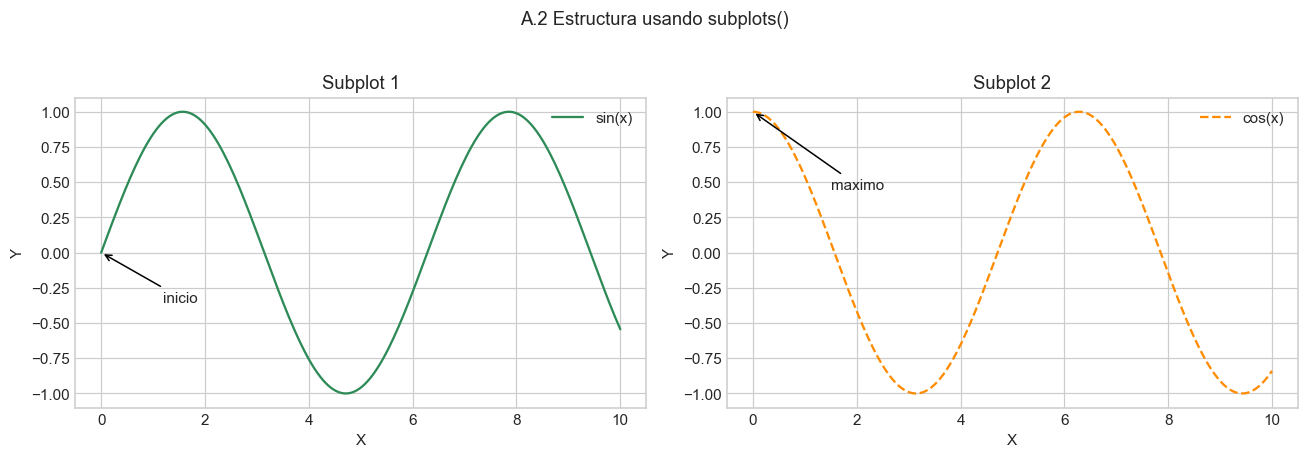

In [4]:
# A.2 Figura con plt.subplots() y multiples ejes
x = np.linspace(0, 10, 200)
y1 = np.sin(x)
y2 = np.cos(x)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=110)

axes[0].plot(x, y1, color='seagreen', label='sin(x)')
axes[0].set_title('Subplot 1')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')
axes[0].legend()
axes[0].annotate('inicio', xy=(0, 0), xytext=(1.2, -0.35), arrowprops=dict(arrowstyle='->'))

axes[1].plot(x, y2, color='darkorange', linestyle='--', label='cos(x)')
axes[1].set_title('Subplot 2')
axes[1].set_xlabel('X')
axes[1].set_ylabel('Y')
axes[1].legend()
axes[1].annotate('maximo', xy=(0, 1), xytext=(1.5, 0.45), arrowprops=dict(arrowstyle='->'))

fig.suptitle('A.2 Estructura usando subplots()', y=1.03)
fig.tight_layout()
fig.savefig(ARTIFACTS_DIR / 'A2_subplots.png', dpi=300, bbox_inches='tight')
plt.show()


## B) Interfaz Pyplot vs API orientada a objetos (OO)

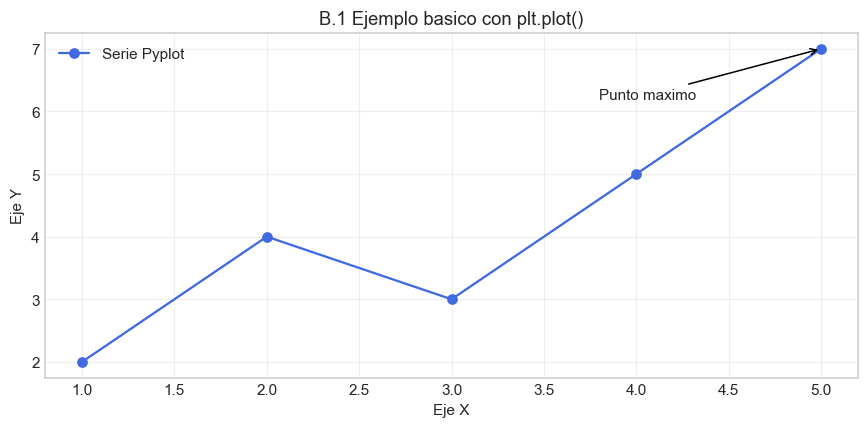

In [5]:
# B.1 Pyplot: interfaz rapida y directa
x_b = [1, 2, 3, 4, 5]
y_b = [2, 4, 3, 5, 7]

plt.figure(figsize=(8, 4), dpi=110)
plt.plot(x_b, y_b, marker='o', color='royalblue', label='Serie Pyplot')
plt.title('B.1 Ejemplo basico con plt.plot()')
plt.xlabel('Eje X')
plt.ylabel('Eje Y')
plt.legend()
plt.grid(alpha=0.3)
plt.annotate('Punto maximo', xy=(5, 7), xytext=(3.8, 6.2), arrowprops=dict(arrowstyle='->'))
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'B1_pyplot.png', dpi=300, bbox_inches='tight')
plt.show()


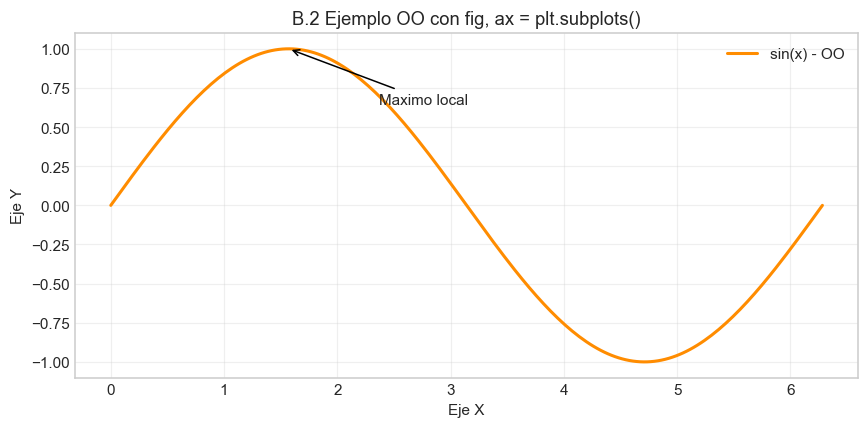

In [6]:
# B.2 OO: mayor control con fig y ax
x_oo = np.linspace(0, 2 * np.pi, 200)
y_oo = np.sin(x_oo)

fig, ax = plt.subplots(figsize=(8, 4), dpi=110)
ax.plot(x_oo, y_oo, color='darkorange', linewidth=2, label='sin(x) - OO')
ax.set_title('B.2 Ejemplo OO con fig, ax = plt.subplots()')
ax.set_xlabel('Eje X')
ax.set_ylabel('Eje Y')
ax.legend()
ax.grid(alpha=0.3)

x_ref = np.pi / 2
y_ref = np.sin(x_ref)
ax.annotate('Maximo local', xy=(x_ref, y_ref), xytext=(x_ref + 0.8, y_ref - 0.35),
            arrowprops=dict(arrowstyle='->'))

fig.tight_layout()
fig.savefig(ARTIFACTS_DIR / 'B2_api_oo.png', dpi=300, bbox_inches='tight')
plt.show()


## C) Graficas univariantes (replicar todas)

In [7]:
# Datos de apoyo para univariantes
uni_data = rng.normal(loc=0, scale=1, size=1000)
groups_data = [rng.normal(0, s, 150) for s in [1, 1.8, 2.5]]

print('uni_data size:', uni_data.size)


uni_data size: 1000


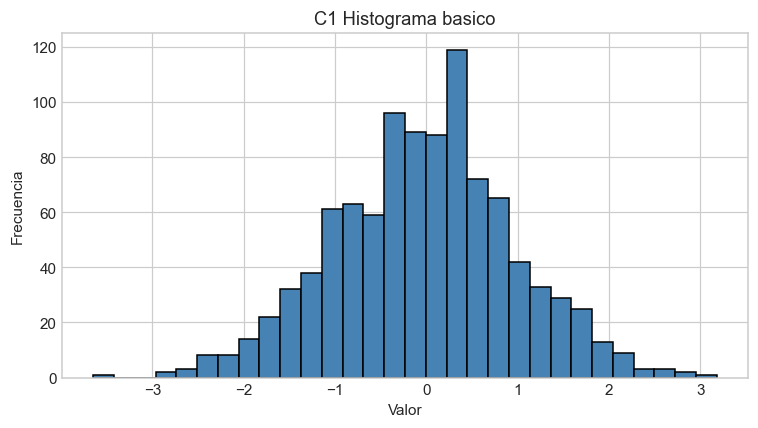

In [8]:
# C1 Histograma basico
fig, ax = plt.subplots(figsize=(7, 4), dpi=110)
ax.hist(uni_data, bins=30, edgecolor='black', color='steelblue')
ax.set_title('C1 Histograma basico')
ax.set_xlabel('Valor')
ax.set_ylabel('Frecuencia')
fig.tight_layout()
fig.savefig(ARTIFACTS_DIR / 'C1_hist_basico.png', dpi=300, bbox_inches='tight')
plt.show()


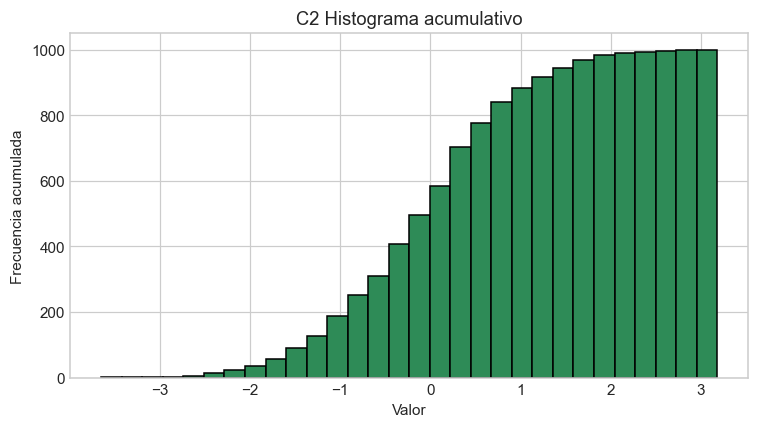

In [9]:
# C2 Histograma acumulativo
fig, ax = plt.subplots(figsize=(7, 4), dpi=110)
ax.hist(uni_data, bins=30, cumulative=True, edgecolor='black', color='seagreen')
ax.set_title('C2 Histograma acumulativo')
ax.set_xlabel('Valor')
ax.set_ylabel('Frecuencia acumulada')
fig.tight_layout()
fig.savefig(ARTIFACTS_DIR / 'C2_hist_acumulativo.png', dpi=300, bbox_inches='tight')
plt.show()


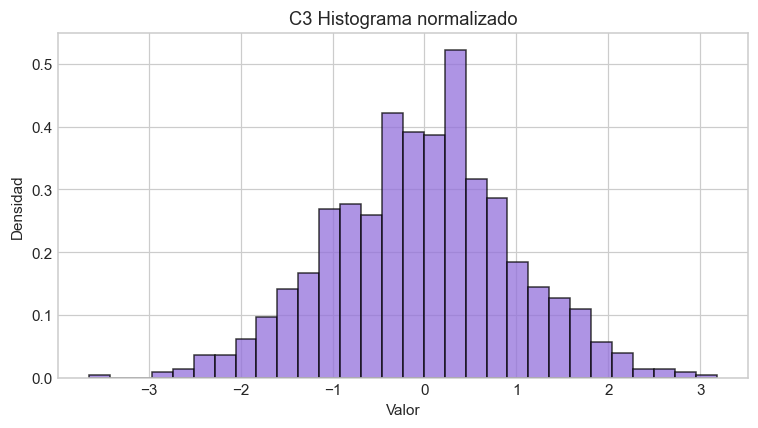

In [10]:
# C3 Histograma normalizado (density=True)
fig, ax = plt.subplots(figsize=(7, 4), dpi=110)
ax.hist(uni_data, bins=30, density=True, edgecolor='black', color='mediumpurple', alpha=0.75)
ax.set_title('C3 Histograma normalizado')
ax.set_xlabel('Valor')
ax.set_ylabel('Densidad')
fig.tight_layout()
fig.savefig(ARTIFACTS_DIR / 'C3_hist_density.png', dpi=300, bbox_inches='tight')
plt.show()


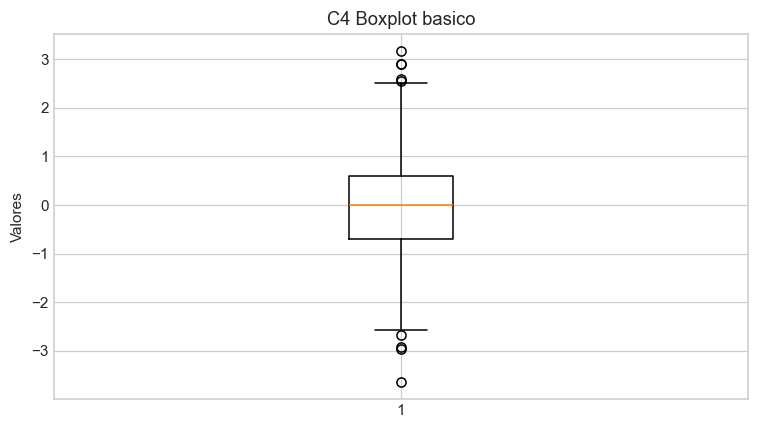

In [11]:
# C4 Boxplot basico
fig, ax = plt.subplots(figsize=(7, 4), dpi=110)
ax.boxplot(uni_data, vert=True)
ax.set_title('C4 Boxplot basico')
ax.set_ylabel('Valores')
fig.tight_layout()
fig.savefig(ARTIFACTS_DIR / 'C4_boxplot_basico.png', dpi=300, bbox_inches='tight')
plt.show()


C:\Users\WILLY-A\AppData\Local\Temp\ipykernel_19036\544548611.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


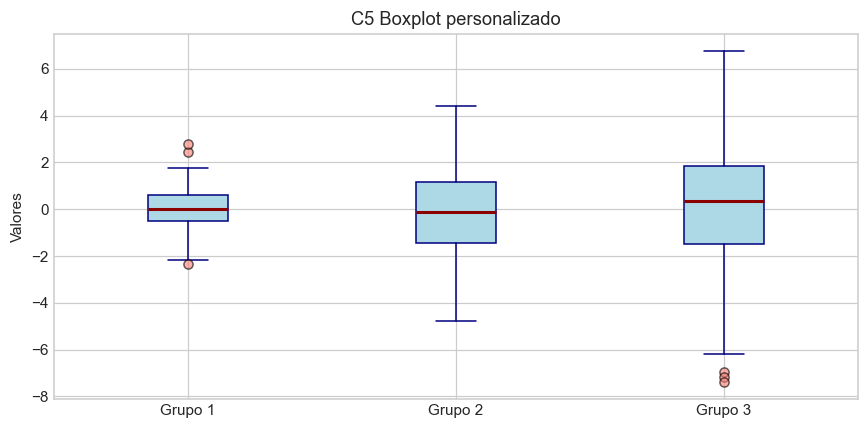

In [12]:
# C5 Boxplot personalizado con colores
fig, ax = plt.subplots(figsize=(8, 4), dpi=110)
ax.boxplot(
    groups_data,
    patch_artist=True,
    labels=['Grupo 1', 'Grupo 2', 'Grupo 3'],
    boxprops=dict(facecolor='lightblue', color='navy'),
    whiskerprops=dict(color='navy'),
    capprops=dict(color='navy'),
    medianprops=dict(color='darkred', linewidth=2),
    flierprops=dict(marker='o', markerfacecolor='salmon', alpha=0.6)
)
ax.set_title('C5 Boxplot personalizado')
ax.set_ylabel('Valores')
fig.tight_layout()
fig.savefig(ARTIFACTS_DIR / 'C5_boxplot_personalizado.png', dpi=300, bbox_inches='tight')
plt.show()


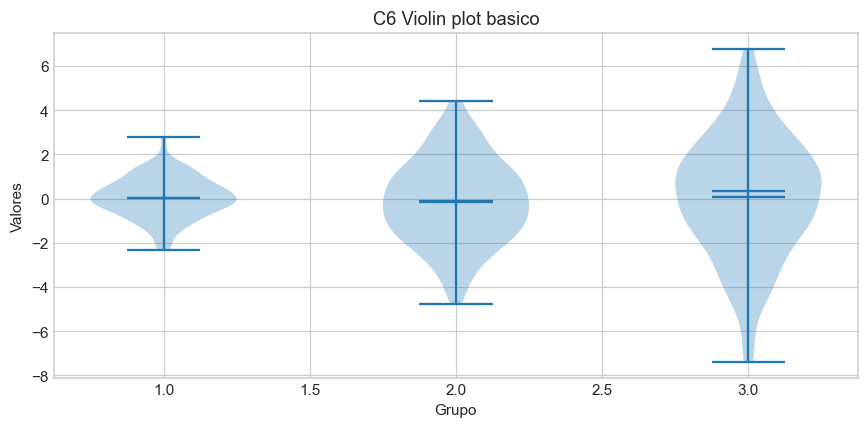

In [13]:
# C6 Violin plot basico
fig, ax = plt.subplots(figsize=(8, 4), dpi=110)
ax.violinplot(groups_data, showmeans=True, showmedians=True)
ax.set_title('C6 Violin plot basico')
ax.set_xlabel('Grupo')
ax.set_ylabel('Valores')
fig.tight_layout()
fig.savefig(ARTIFACTS_DIR / 'C6_violin_basico.png', dpi=300, bbox_inches='tight')
plt.show()


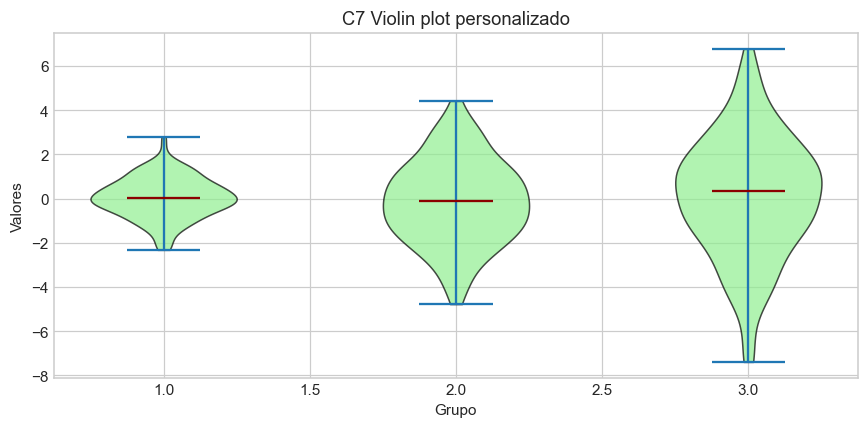

In [14]:
# C7 Violin plot personalizado
fig, ax = plt.subplots(figsize=(8, 4), dpi=110)
parts = ax.violinplot(groups_data, showmeans=False, showmedians=True)
for body in parts['bodies']:
    body.set_facecolor('lightgreen')
    body.set_edgecolor('black')
    body.set_alpha(0.7)
parts['cmedians'].set_edgecolor('darkred')
ax.set_title('C7 Violin plot personalizado')
ax.set_xlabel('Grupo')
ax.set_ylabel('Valores')
fig.tight_layout()
fig.savefig(ARTIFACTS_DIR / 'C7_violin_personalizado.png', dpi=300, bbox_inches='tight')
plt.show()


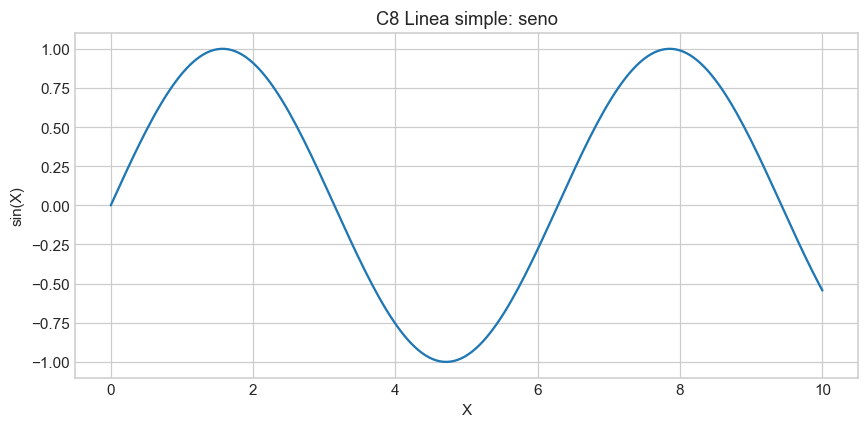

In [15]:
# C8 Grafica de linea simple (seno)
x = np.linspace(0, 10, 200)
y = np.sin(x)

fig, ax = plt.subplots(figsize=(8, 4), dpi=110)
ax.plot(x, y)
ax.set_title('C8 Linea simple: seno')
ax.set_xlabel('X')
ax.set_ylabel('sin(X)')
fig.tight_layout()
fig.savefig(ARTIFACTS_DIR / 'C8_linea_simple_seno.png', dpi=300, bbox_inches='tight')
plt.show()


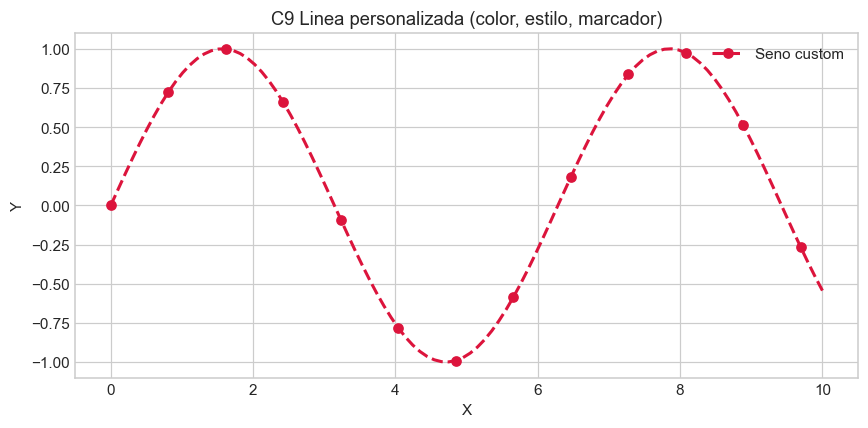

In [16]:
# C9 Grafica de linea personalizada
x = np.linspace(0, 10, 100)
y = np.sin(x)

fig, ax = plt.subplots(figsize=(8, 4), dpi=110)
ax.plot(x, y, color='crimson', linestyle='--', marker='o', markevery=8, linewidth=2, label='Seno custom')
ax.set_title('C9 Linea personalizada (color, estilo, marcador)')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.legend()
fig.tight_layout()
fig.savefig(ARTIFACTS_DIR / 'C9_linea_personalizada.png', dpi=300, bbox_inches='tight')
plt.show()


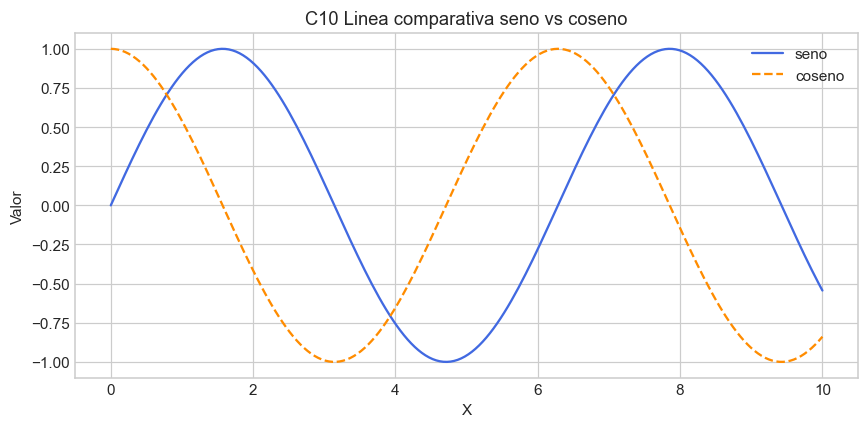

In [17]:
# C10 Grafica comparativa (seno vs coseno)
x = np.linspace(0, 10, 200)
y1 = np.sin(x)
y2 = np.cos(x)

fig, ax = plt.subplots(figsize=(8, 4), dpi=110)
ax.plot(x, y1, label='seno', color='royalblue')
ax.plot(x, y2, label='coseno', color='darkorange', linestyle='--')
ax.set_title('C10 Linea comparativa seno vs coseno')
ax.set_xlabel('X')
ax.set_ylabel('Valor')
ax.legend()
fig.tight_layout()
fig.savefig(ARTIFACTS_DIR / 'C10_linea_comparativa.png', dpi=300, bbox_inches='tight')
plt.show()


## D) Graficas bivariantes (replicar todas)

In [18]:
# Datos de apoyo para bivariantes
x_b = rng.random(120)
y_b = 0.6 * x_b + rng.normal(0, 0.1, 120)
size_b = rng.random(120) * 700
color_b = rng.random(120)

print('x_b size:', x_b.size)


x_b size: 120


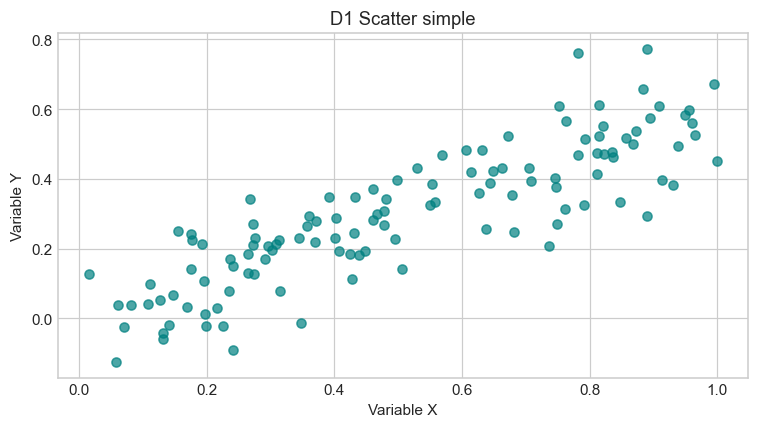

In [19]:
# D1 Scatter plot simple
fig, ax = plt.subplots(figsize=(7, 4), dpi=110)
ax.scatter(x_b, y_b, color='teal', alpha=0.7)
ax.set_title('D1 Scatter simple')
ax.set_xlabel('Variable X')
ax.set_ylabel('Variable Y')
fig.tight_layout()
fig.savefig(ARTIFACTS_DIR / 'D1_scatter_simple.png', dpi=300, bbox_inches='tight')
plt.show()


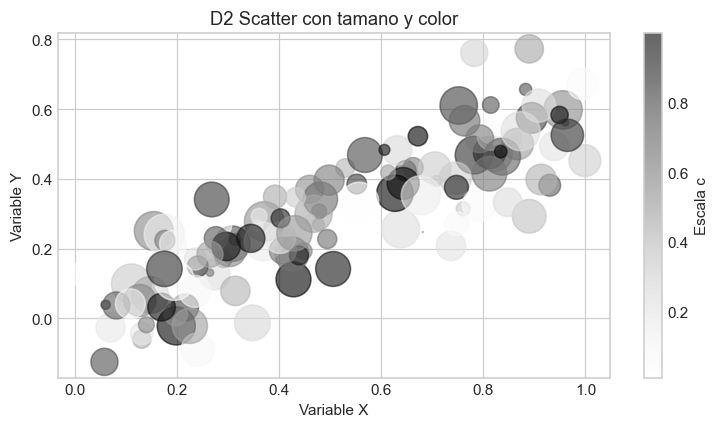

In [20]:
# D2 Scatter con tamano (s) y color (c)
fig, ax = plt.subplots(figsize=(7, 4), dpi=110)
sc = ax.scatter(x_b, y_b, s=size_b, c=color_b, alpha=0.6)
ax.set_title('D2 Scatter con tamano y color')
ax.set_xlabel('Variable X')
ax.set_ylabel('Variable Y')
fig.colorbar(sc, ax=ax, label='Escala c')
fig.tight_layout()
fig.savefig(ARTIFACTS_DIR / 'D2_scatter_size_color.png', dpi=300, bbox_inches='tight')
plt.show()


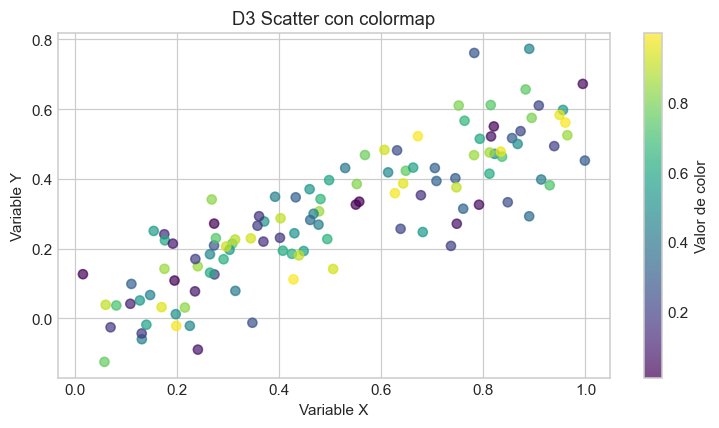

In [21]:
# D3 Scatter con mapa de color (colormap)
fig, ax = plt.subplots(figsize=(7, 4), dpi=110)
sc = ax.scatter(x_b, y_b, c=color_b, cmap='viridis', alpha=0.7)
ax.set_title('D3 Scatter con colormap')
ax.set_xlabel('Variable X')
ax.set_ylabel('Variable Y')
fig.colorbar(sc, ax=ax, label='Valor de color')
fig.tight_layout()
fig.savefig(ARTIFACTS_DIR / 'D3_scatter_colormap.png', dpi=300, bbox_inches='tight')
plt.show()


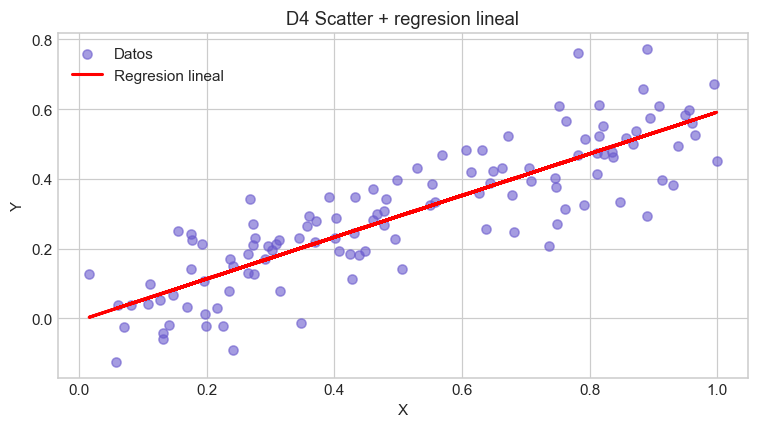

In [22]:
# D4 Scatter con linea de regresion lineal
m, b = np.polyfit(x_b, y_b, 1)

fig, ax = plt.subplots(figsize=(7, 4), dpi=110)
ax.scatter(x_b, y_b, color='slateblue', alpha=0.6, label='Datos')
ax.plot(x_b, m * x_b + b, color='red', linewidth=2, label='Regresion lineal')
ax.set_title('D4 Scatter + regresion lineal')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.legend()
fig.tight_layout()
fig.savefig(ARTIFACTS_DIR / 'D4_scatter_regresion_lineal.png', dpi=300, bbox_inches='tight')
plt.show()


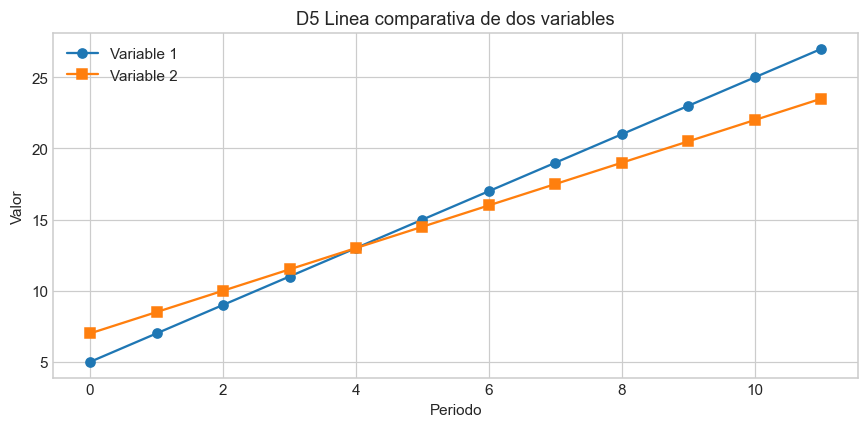

In [23]:
# D5 Grafica de linea comparativa de dos variables
x = np.arange(0, 12)
var_1 = 2 * x + 5
var_2 = 1.5 * x + 7

fig, ax = plt.subplots(figsize=(8, 4), dpi=110)
ax.plot(x, var_1, marker='o', label='Variable 1')
ax.plot(x, var_2, marker='s', label='Variable 2')
ax.set_title('D5 Linea comparativa de dos variables')
ax.set_xlabel('Periodo')
ax.set_ylabel('Valor')
ax.legend()
fig.tight_layout()
fig.savefig(ARTIFACTS_DIR / 'D5_linea_comparativa_2variables.png', dpi=300, bbox_inches='tight')
plt.show()


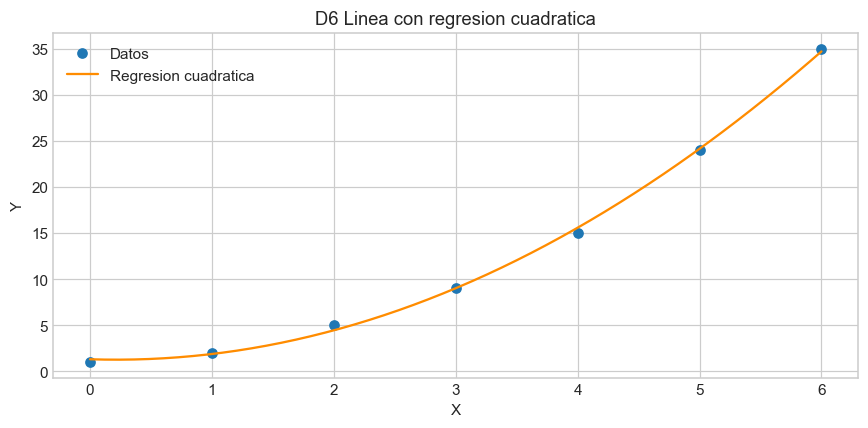

In [24]:
# D6 Linea con regresion cuadratica
x_q = np.array([0, 1, 2, 3, 4, 5, 6])
y_q = np.array([1, 2, 5, 9, 15, 24, 35])
coef = np.polyfit(x_q, y_q, 2)
poly = np.poly1d(coef)

fig, ax = plt.subplots(figsize=(8, 4), dpi=110)
ax.plot(x_q, y_q, 'o', label='Datos')
xx = np.linspace(x_q.min(), x_q.max(), 200)
ax.plot(xx, poly(xx), color='darkorange', label='Regresion cuadratica')
ax.set_title('D6 Linea con regresion cuadratica')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.legend()
fig.tight_layout()
fig.savefig(ARTIFACTS_DIR / 'D6_regresion_cuadratica.png', dpi=300, bbox_inches='tight')
plt.show()


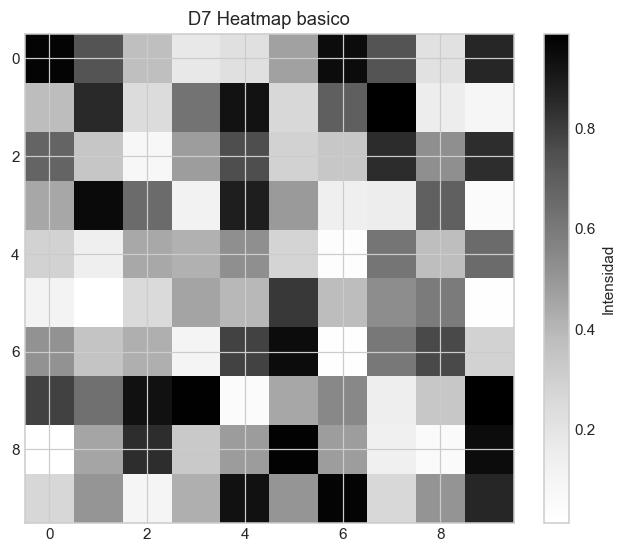

In [25]:
# D7 Heatmap basico con imshow()
mat = rng.random((10, 10))

fig, ax = plt.subplots(figsize=(6, 5), dpi=110)
im = ax.imshow(mat)
ax.set_title('D7 Heatmap basico')
fig.colorbar(im, ax=ax, label='Intensidad')
fig.tight_layout()
fig.savefig(ARTIFACTS_DIR / 'D7_heatmap_basico.png', dpi=300, bbox_inches='tight')
plt.show()


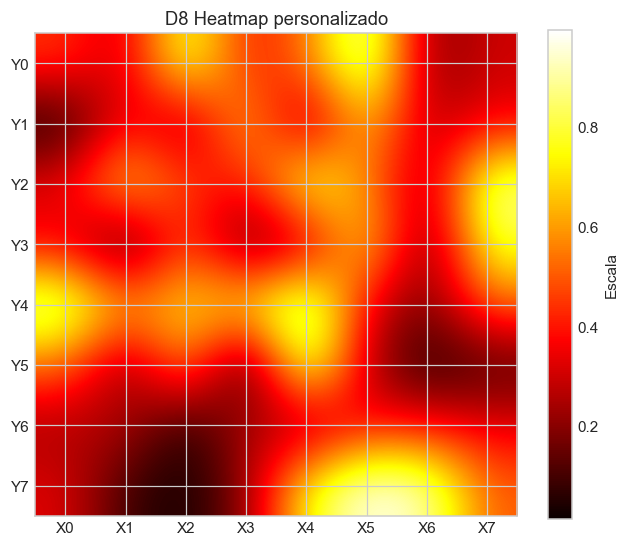

In [26]:
# D8 Heatmap personalizado (cmap, ticks, interpolacion)
mat2 = rng.random((8, 8))

fig, ax = plt.subplots(figsize=(6, 5), dpi=110)
im = ax.imshow(mat2, cmap='hot', interpolation='bicubic')
ax.set_title('D8 Heatmap personalizado')
ax.set_xticks(np.arange(8))
ax.set_yticks(np.arange(8))
ax.set_xticklabels([f'X{i}' for i in range(8)])
ax.set_yticklabels([f'Y{i}' for i in range(8)])
fig.colorbar(im, ax=ax, label='Escala')
fig.tight_layout()
fig.savefig(ARTIFACTS_DIR / 'D8_heatmap_personalizado.png', dpi=300, bbox_inches='tight')
plt.show()


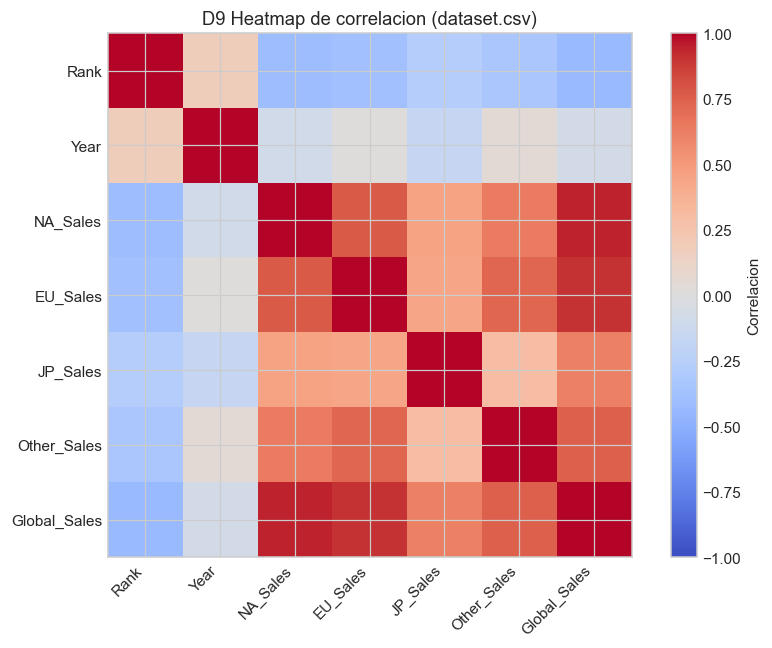

In [27]:
# D9 Heatmap de matriz de correlacion (dataset real)
num_cols = df.select_dtypes(include=[np.number])
corr = num_cols.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(8, 6), dpi=110)
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_title('D9 Heatmap de correlacion (dataset.csv)')
ax.set_xticks(np.arange(len(corr.columns)))
ax.set_yticks(np.arange(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)
fig.colorbar(im, ax=ax, label='Correlacion')
fig.tight_layout()
fig.savefig(ARTIFACTS_DIR / 'D9_heatmap_correlacion.png', dpi=300, bbox_inches='tight')
plt.show()


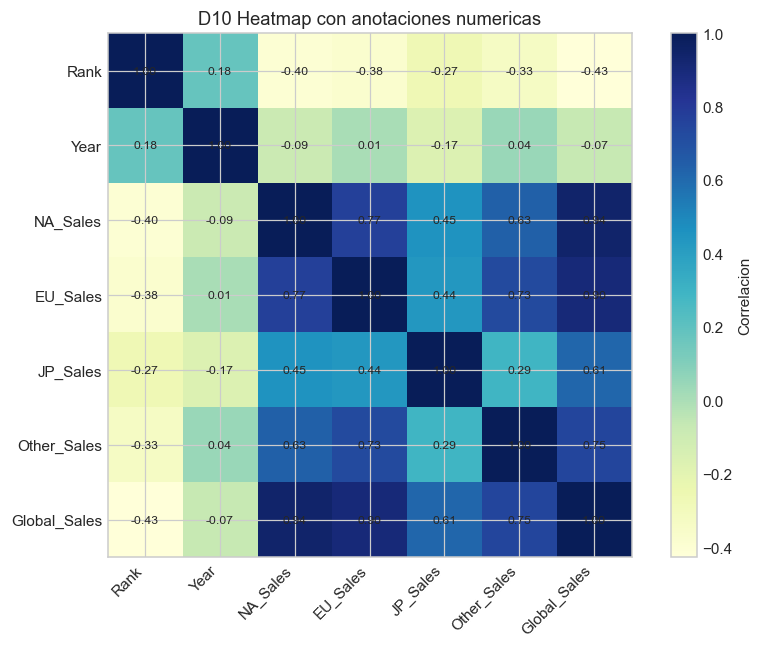

In [28]:
# D10 Heatmap con anotaciones numericas
fig, ax = plt.subplots(figsize=(8, 6), dpi=110)
im = ax.imshow(corr, cmap='YlGnBu')
ax.set_title('D10 Heatmap con anotaciones numericas')
ax.set_xticks(np.arange(len(corr.columns)))
ax.set_yticks(np.arange(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)

for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)

fig.colorbar(im, ax=ax, label='Correlacion')
fig.tight_layout()
fig.savefig(ARTIFACTS_DIR / 'D10_heatmap_anotado.png', dpi=300, bbox_inches='tight')
plt.show()


## E) Graficas categoricas (replicar todas)

In [29]:
# Datos categoricos de ejemplo
categorias = ['A', 'B', 'C', 'D']
valores1 = np.array([3, 2, 5, 7])
valores2 = np.array([4, 6, 2, 5])


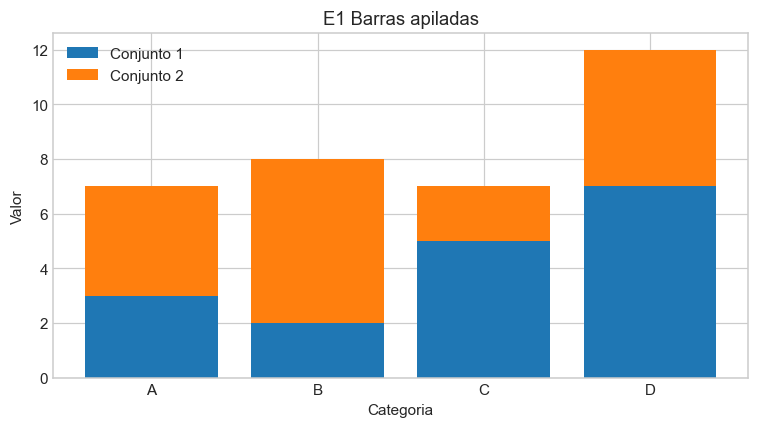

In [30]:
# E1 Barras apiladas
fig, ax = plt.subplots(figsize=(7, 4), dpi=110)
ax.bar(categorias, valores1, label='Conjunto 1')
ax.bar(categorias, valores2, bottom=valores1, label='Conjunto 2')
ax.set_title('E1 Barras apiladas')
ax.set_xlabel('Categoria')
ax.set_ylabel('Valor')
ax.legend()
fig.tight_layout()
fig.savefig(ARTIFACTS_DIR / 'E1_barras_apiladas.png', dpi=300, bbox_inches='tight')
plt.show()


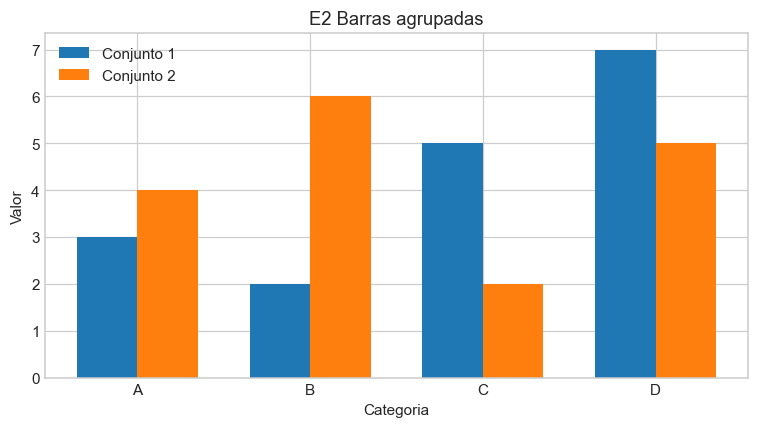

In [31]:
# E2 Barras agrupadas
x = np.arange(len(categorias))
ancho = 0.35

fig, ax = plt.subplots(figsize=(7, 4), dpi=110)
ax.bar(x - ancho / 2, valores1, width=ancho, label='Conjunto 1')
ax.bar(x + ancho / 2, valores2, width=ancho, label='Conjunto 2')
ax.set_title('E2 Barras agrupadas')
ax.set_xlabel('Categoria')
ax.set_ylabel('Valor')
ax.set_xticks(x)
ax.set_xticklabels(categorias)
ax.legend()
fig.tight_layout()
fig.savefig(ARTIFACTS_DIR / 'E2_barras_agrupadas.png', dpi=300, bbox_inches='tight')
plt.show()


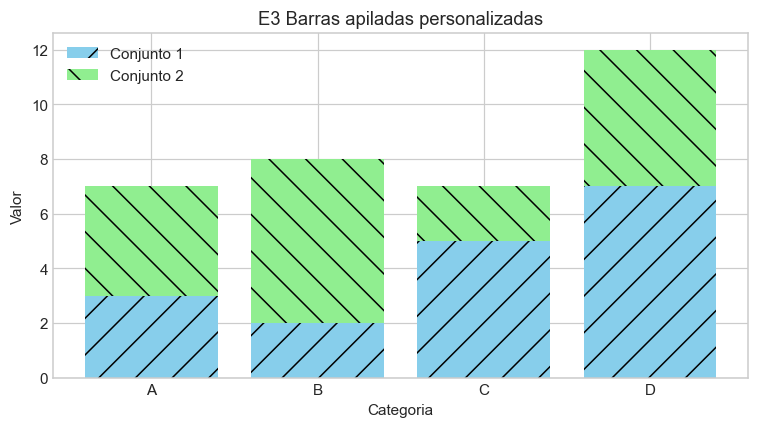

In [32]:
# E3 Barras apiladas personalizadas (colores + hatch)
fig, ax = plt.subplots(figsize=(7, 4), dpi=110)
ax.bar(categorias, valores1, color='skyblue', hatch='/', label='Conjunto 1')
ax.bar(categorias, valores2, bottom=valores1, color='lightgreen', hatch='\\', label='Conjunto 2')
ax.set_title('E3 Barras apiladas personalizadas')
ax.set_xlabel('Categoria')
ax.set_ylabel('Valor')
ax.legend()
fig.tight_layout()
fig.savefig(ARTIFACTS_DIR / 'E3_barras_apiladas_personalizadas.png', dpi=300, bbox_inches='tight')
plt.show()


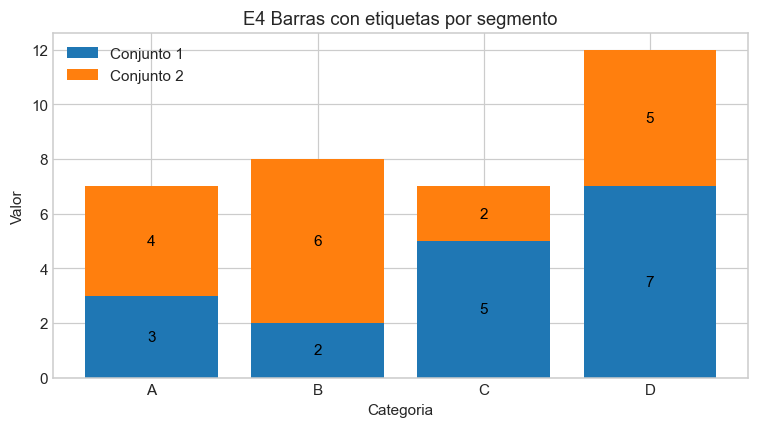

In [33]:
# E4 Barras con etiquetas numericas sobre cada segmento
fig, ax = plt.subplots(figsize=(7, 4), dpi=110)
b1 = ax.bar(categorias, valores1, label='Conjunto 1')
b2 = ax.bar(categorias, valores2, bottom=valores1, label='Conjunto 2')

for i, (v1, v2) in enumerate(zip(valores1, valores2)):
    ax.text(i, v1 / 2, str(v1), ha='center', va='center', color='black')
    ax.text(i, v1 + v2 / 2, str(v2), ha='center', va='center', color='black')

ax.set_title('E4 Barras con etiquetas por segmento')
ax.set_xlabel('Categoria')
ax.set_ylabel('Valor')
ax.legend()
fig.tight_layout()
fig.savefig(ARTIFACTS_DIR / 'E4_barras_etiquetas_segmento.png', dpi=300, bbox_inches='tight')
plt.show()


## Reflexion tecnica final

1. **Cual grafica fue mas util para interpretar datos y por que?**
El heatmap de correlacion fue muy util para leer relaciones entre variables numericas del dataset real en una sola vista.

2. **Que diferencias notaste entre Pyplot y la API OO?**
Pyplot es mas rapido para ejemplos cortos; la API OO facilita mantener orden y control cuando hay varias figuras y personalizacion.

3. **Que tipo de grafica consideras mas adecuada para tu proyecto personal?**
Una combinacion de histogramas, boxplots y scatter, porque permite ver distribucion, valores atipicos y relaciones entre variables.


In [34]:
# Verificacion rapida de evidencias guardadas con savefig()
files = sorted(ARTIFACTS_DIR.glob('*.png'))
print('Total de figuras guardadas:', len(files))
for f in files:
    print('-', f.name)


Total de figuras guardadas: 28
- A1_figure_add_subplot.png
- A2_subplots.png
- B1_pyplot.png
- B2_api_oo.png
- C10_linea_comparativa.png
- C1_hist_basico.png
- C2_hist_acumulativo.png
- C3_hist_density.png
- C4_boxplot_basico.png
- C5_boxplot_personalizado.png
- C6_violin_basico.png
- C7_violin_personalizado.png
- C8_linea_simple_seno.png
- C9_linea_personalizada.png
- D10_heatmap_anotado.png
- D1_scatter_simple.png
- D2_scatter_size_color.png
- D3_scatter_colormap.png
- D4_scatter_regresion_lineal.png
- D5_linea_comparativa_2variables.png
- D6_regresion_cuadratica.png
- D7_heatmap_basico.png
- D8_heatmap_personalizado.png
- D9_heatmap_correlacion.png
- E1_barras_apiladas.png
- E2_barras_agrupadas.png
- E3_barras_apiladas_personalizadas.png
- E4_barras_etiquetas_segmento.png
